# 04. Laboratório de Modelos, Experimentos Temporais e Avaliação Cega

Este notebook concentra a esteira de modelagem, corrigida e ampliada:
1. Pré-processamento blindado via `TemporalPreprocessor`.
2. Modelos Baselines e Algoritmo do Zero em D0.
3. **Ajuste de hiperparâmetros do Modelo Principal com TimeSeriesSplit em D0.**
4. Estratégias temporais: M0, MFT (com **duas configurações testadas**), MRT, MREC.
5. Métricas completas (Accuracy, Precision, Recall, F1, PR-AUC, MCC, matriz de confusão).
6. Explicabilidade comparativa (SHAP: M0 vs. modelo atualizado).
7. Análise de erros (falsos positivos/negativos com exemplos reais).
8. Tabela 17 (Avaliação cega final em D2, com variação percentual vs. M0).

In [1]:
import sys
import os
import copy
import time
import warnings

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, matthews_corrcoef
)

sys.path.append(os.path.abspath('..'))
from src.data_processing import TemporalPreprocessor
from src.custom_models import LogisticRegressionCustom

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

SEEDS = [42, 123, 999]

# 1. Carga de Dados (mantendo colunas originais para análise de erros posterior)
d0 = pd.read_csv('../data/processed/d0.csv')
d1 = pd.read_csv('../data/processed/d1.csv')
d2 = pd.read_csv('../data/processed/d2.csv')

# 2. Pré-processamento Restrito (fit exclusivamente em D0)
preprocessor = TemporalPreprocessor()
X0, y0 = preprocessor.fit(d0).transform(d0)
X1, y1 = preprocessor.transform(d1)
X2, y2 = preprocessor.transform(d2)

# Conjunto Acumulado (Para o Retreinamento Completo)
X01 = np.vstack([X0, X1])
y01 = np.concatenate([y0, y1])

print(f"Shape X0: {X0.shape} | X1: {X1.shape} | X2: {X2.shape}")

c:\Users\55449\Documents\GitHub\spotify-charts-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape X0: (163932, 19) | X1: (57497, 19) | X2: (51350, 19)


## 1. Algoritmo do Zero vs. Baseline da Biblioteca (US05 e US06)

Comparação entre a Regressão Logística implementada do zero (NumPy), sua equivalente em scikit-learn, e um baseline de árvores (Random Forest), todos treinados em D0 e validados em D1.

In [2]:
print("--- Regressão Logística Customizada (NumPy) ---")
start = time.time()
custom_lr = LogisticRegressionCustom(learning_rate=0.1, num_iterations=500)
custom_lr.fit(X0, y0)
y_pred_custom = custom_lr.predict(X1)
print(f"F1-Score (Validação em D1): {f1_score(y1, y_pred_custom):.4f} | Tempo: {time.time() - start:.2f}s")

print("\n--- Regressão Logística (Scikit-Learn) ---")
start = time.time()
sk_lr = LogisticRegression(max_iter=500, random_state=42)
sk_lr.fit(X0, y0)
y_pred_sk = sk_lr.predict(X1)
print(f"F1-Score (Validação em D1): {f1_score(y1, y_pred_sk):.4f} | Tempo: {time.time() - start:.2f}s")

print("\n--- Baseline Árvores (Random Forest) ---")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X0, y0)
y_pred_rf = rf.predict(X1)
print(f"F1-Score (Validação em D1): {f1_score(y1, y_pred_rf):.4f}")

print("\nResumo: as três famílias de modelos (Regressão Logística, Random Forest, e o MLP")
print("definido a seguir como Modelo Principal) atendem ao requisito de n=3 famílias treinadas.")

--- Regressão Logística Customizada (NumPy) ---
F1-Score (Validação em D1): 0.3131 | Tempo: 6.68s

--- Regressão Logística (Scikit-Learn) ---
F1-Score (Validação em D1): 0.2997 | Tempo: 0.35s

--- Baseline Árvores (Random Forest) ---
F1-Score (Validação em D1): 0.2194

Resumo: as três famílias de modelos (Regressão Logística, Random Forest, e o MLP
definido a seguir como Modelo Principal) atendem ao requisito de n=3 famílias treinadas.


## 2. Ajuste de Hiperparâmetros do Modelo Principal (US04 / Item 6.9)

O ajuste é realizado **exclusivamente em D0**, utilizando `TimeSeriesSplit` (3 folds) para preservar a ordem cronológica dos dados — nenhuma informação futura vaza para o passado durante a validação. Testamos combinações de arquitetura (`hidden_layer_sizes`), taxa de aprendizado (`learning_rate_init`) e regularização (`alpha`), selecionando a configuração com maior F1-Score médio nos folds de validação.

In [3]:
param_grid = [
    {'hidden_layer_sizes': (32,),      'learning_rate_init': 0.001, 'alpha': 0.0001},
    {'hidden_layer_sizes': (64, 32),   'learning_rate_init': 0.001, 'alpha': 0.0001},
    {'hidden_layer_sizes': (64, 32),   'learning_rate_init': 0.01,  'alpha': 0.001},
    {'hidden_layer_sizes': (128, 64),  'learning_rate_init': 0.001, 'alpha': 0.0001},
]

tscv = TimeSeriesSplit(n_splits=3)
tuning_results = []

print("Executando busca de hiperparâmetros com TimeSeriesSplit (pode levar alguns minutos)...")

for params in param_grid:
    fold_f1 = []
    for train_idx, val_idx in tscv.split(X0):
        X_tr, X_val = X0[train_idx], X0[val_idx]
        y_tr, y_val = y0[train_idx], y0[val_idx]

        mlp = MLPClassifier(
            max_iter=50,
            random_state=42,
            early_stopping=True,
            n_iter_no_change=5,
            **params
        )
        mlp.fit(X_tr, y_tr)
        y_pred = mlp.predict(X_val)
        fold_f1.append(f1_score(y_val, y_pred, zero_division=0))

    tuning_results.append({
        **params,
        'F1_mean': np.mean(fold_f1),
        'F1_std': np.std(fold_f1)
    })

df_tuning = pd.DataFrame(tuning_results).sort_values('F1_mean', ascending=False).reset_index(drop=True)
display(df_tuning)

best_config = df_tuning.iloc[0]
best_params = {
    'hidden_layer_sizes': best_config['hidden_layer_sizes'],
    'learning_rate_init': best_config['learning_rate_init'],
    'alpha': best_config['alpha']
}
print(f"\nMelhor configuração encontrada: {best_params} (F1 médio = {best_config['F1_mean']:.4f})")

Executando busca de hiperparâmetros com TimeSeriesSplit (pode levar alguns minutos)...


,hidden_layer_sizes,learning_rate_init,alpha,F1_mean,F1_std
0,"(128, 64)",0.001,0.0001,0.263299,0.015681
1,"(32,)",0.001,0.0001,0.256286,0.005156
2,"(64, 32)",0.001,0.0001,0.252968,0.031516
3,"(64, 32)",0.010,0.0010,0.243434,0.019109



Melhor configuração encontrada: {'hidden_layer_sizes': (128, 64), 'learning_rate_init': np.float64(0.001), 'alpha': np.float64(0.0001)} (F1 médio = 0.2633)


## 3. Experimentos Temporais: M0, MFT, MRT, MREC

Usamos a configuração vencedora do ajuste de hiperparâmetros como arquitetura base do Modelo Principal (MLP), mantida constante em todos os experimentos para que a única variável relevante seja a estratégia de atualização dos dados/pesos. Todos os treinamentos são executados com 3 seeds diferentes, reportando média ± desvio-padrão das métricas.

In [4]:
def train_eval_mlp(X_train, y_train, X_test, y_test, model_params,
                    warm_start_models=None, extra_iter=30, base_max_iter=50):
    """
    Treina e avalia o MLP para as 3 seeds definidas em SEEDS.

    - warm_start_models=None -> inicializa o modelo do zero (pesos aleatórios) para cada seed.
    - warm_start_models=[m0_seed1, m0_seed2, m0_seed3] -> continua o treinamento a partir
      dos pesos já existentes de cada modelo correspondente (fine-tuning), sem reiniciar pesos.

    Retorna: (dict de métricas resumidas, matriz de confusão média, lista de modelos treinados,
              DataFrame com métricas por seed)
    """
    metrics_list = []
    conf_matrices = []
    trained_models = []

    for i, seed in enumerate(SEEDS):
        if warm_start_models is not None:
            # Fine-tuning: parte dos pesos já treinados do modelo correspondente (mesma seed)
            mlp = copy.deepcopy(warm_start_models[i])
            mlp.set_params(max_iter=extra_iter)
            if 'learning_rate_init' in model_params:
                mlp.set_params(learning_rate_init=model_params['learning_rate_init'])
            if 'alpha' in model_params:
                mlp.set_params(alpha=model_params['alpha'])
        else:
            # Inicialização do zero (pesos aleatórios), conforme RN04.1/RN07.2/RN08.1
            params = dict(model_params)
            params['random_state'] = seed
            params.setdefault('max_iter', base_max_iter)
            params.setdefault('warm_start', True)
            mlp = MLPClassifier(**params)

        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)
        y_prob = mlp.predict_proba(X_test)[:, 1]

        metrics_list.append({
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'MCC': matthews_corrcoef(y_test, y_pred)
        })
        conf_matrices.append(confusion_matrix(y_test, y_pred))
        trained_models.append(mlp)

    df_metrics = pd.DataFrame(metrics_list)
    summary = {}
    for col in df_metrics.columns:
        summary[f'{col}_mean'] = df_metrics[col].mean()
        summary[f'{col}_std'] = df_metrics[col].std()

    avg_conf_matrix = np.mean(conf_matrices, axis=0)

    return summary, avg_conf_matrix, trained_models, df_metrics


base_params = {**best_params, 'warm_start': True}

print("=== M0: Treinamento Histórico (somente D0), pesos aleatórios ===")
summary_m0, cm_m0, models_m0, df_m0 = train_eval_mlp(X0, y0, X2, y2, base_params, base_max_iter=50)
print(f"F1 (D2): {summary_m0['F1_mean']:.4f} ± {summary_m0['F1_std']:.4f}")

=== M0: Treinamento Histórico (somente D0), pesos aleatórios ===
F1 (D2): 0.2783 ± 0.0107


### 3.1 Fine-Tuning (MFT) — Duas Configurações Testadas (Item 6.12)

Partindo dos pesos de cada modelo M0 (mesma seed), continuamos o treinamento **apenas com D1**, testando duas configurações distintas:

- **Config A (conservadora):** learning rate reduzido e poucas épocas extras — objetivo de ajustar sutilmente os pesos sem "esquecer" o conhecimento histórico.
- **Config B (agressiva):** learning rate maior, mais épocas extras e regularização (alpha) mais forte — objetivo de adaptar mais fortemente o modelo ao padrão recente, com risco maior de overfitting/esquecimento catastrófico.

A configuração com melhor F1 em D2 será adotada como **MFT oficial** na Tabela 17.

In [5]:
print("=== MFT - Config A (conservadora): lr menor, poucas épocas ===")
mft_config_a = {'learning_rate_init': 0.0005}
summary_mft_a, cm_mft_a, models_mft_a, df_mft_a = train_eval_mlp(
    X1, y1, X2, y2, mft_config_a, warm_start_models=models_m0, extra_iter=10
)
print(f"F1 (D2): {summary_mft_a['F1_mean']:.4f} ± {summary_mft_a['F1_std']:.4f}")

print("\n=== MFT - Config B (agressiva): lr maior, mais épocas, mais regularização ===")
mft_config_b = {'learning_rate_init': 0.01, 'alpha': 0.001}
summary_mft_b, cm_mft_b, models_mft_b, df_mft_b = train_eval_mlp(
    X1, y1, X2, y2, mft_config_b, warm_start_models=models_m0, extra_iter=40
)
print(f"F1 (D2): {summary_mft_b['F1_mean']:.4f} ± {summary_mft_b['F1_std']:.4f}")

# Seleciona a melhor configuração de fine-tuning com base no F1 médio em D2
if summary_mft_a['F1_mean'] >= summary_mft_b['F1_mean']:
    summary_mft, cm_mft, models_mft, df_mft = summary_mft_a, cm_mft_a, models_mft_a, df_mft_a
    mft_config_vencedora = "Config A (conservadora)"
else:
    summary_mft, cm_mft, models_mft, df_mft = summary_mft_b, cm_mft_b, models_mft_b, df_mft_b
    mft_config_vencedora = "Config B (agressiva)"

print(f"\n>> Configuração de fine-tuning adotada como MFT oficial: {mft_config_vencedora}")

comparativo_ft = pd.DataFrame([
    {"Configuração": "A - Conservadora", "learning_rate_init": 0.0005, "extra_iter": 10, "F1 (D2)": f"{summary_mft_a['F1_mean']:.4f} ± {summary_mft_a['F1_std']:.4f}"},
    {"Configuração": "B - Agressiva", "learning_rate_init": 0.01, "alpha": 0.001, "extra_iter": 40, "F1 (D2)": f"{summary_mft_b['F1_mean']:.4f} ± {summary_mft_b['F1_std']:.4f}"}
])
display(comparativo_ft)

=== MFT - Config A (conservadora): lr menor, poucas épocas ===
F1 (D2): 0.2781 ± 0.0325

=== MFT - Config B (agressiva): lr maior, mais épocas, mais regularização ===
F1 (D2): 0.2383 ± 0.0459

>> Configuração de fine-tuning adotada como MFT oficial: Config A (conservadora)


,Configuração,learning_rate_init,extra_iter,F1 (D2),alpha
0,A - Conservadora,0.0005,10,0.2781 ± 0.0325,NaN
1,B - Agressiva,0.0100,40,0.2383 ± 0.0459,0.001


In [6]:
print("=== MRT: Retreinamento Completo (D0 + D1), pesos reiniciados ===")
summary_mrt, cm_mrt, models_mrt, df_mrt = train_eval_mlp(X01, y01, X2, y2, base_params, base_max_iter=50)
print(f"F1 (D2): {summary_mrt['F1_mean']:.4f} ± {summary_mrt['F1_std']:.4f}")

print("\n=== MREC: Treinamento apenas com D1, pesos reiniciados ===")
summary_mrec, cm_mrec, models_mrec, df_mrec = train_eval_mlp(X1, y1, X2, y2, base_params, base_max_iter=50)
print(f"F1 (D2): {summary_mrec['F1_mean']:.4f} ± {summary_mrec['F1_std']:.4f}")

=== MRT: Retreinamento Completo (D0 + D1), pesos reiniciados ===
F1 (D2): 0.2962 ± 0.0123

=== MREC: Treinamento apenas com D1, pesos reiniciados ===
F1 (D2): 0.3260 ± 0.0148


### 3.2 Matrizes de Confusão (média entre as 3 seeds)

As matrizes abaixo consolidam a média (arredondada) das matrizes de confusão obtidas nas 3 seeds de cada estratégia, avaliadas em D2.

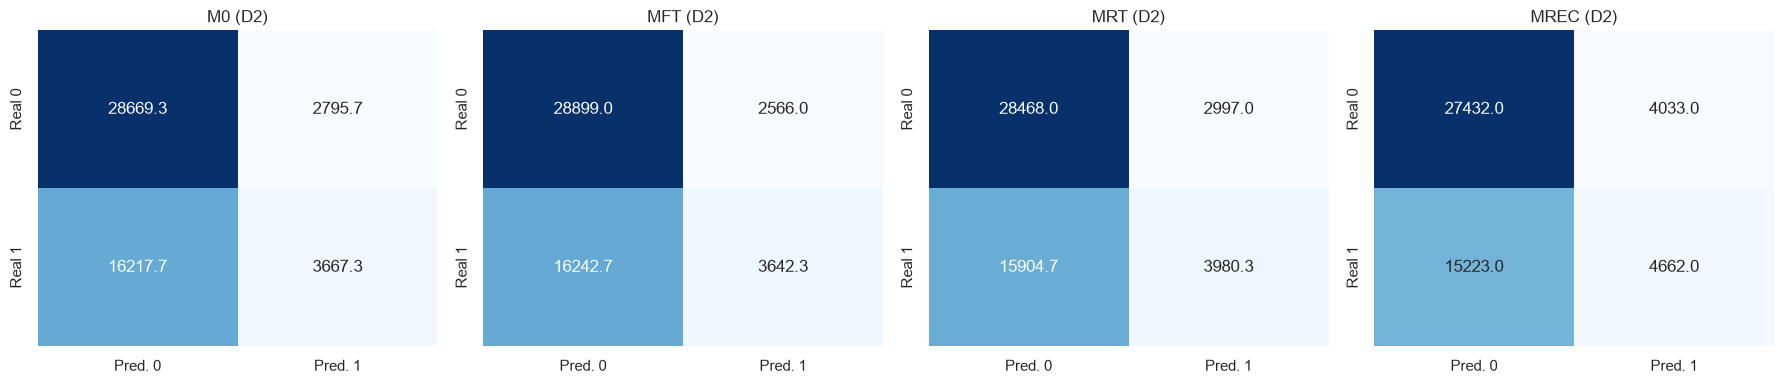

In [7]:
matrizes = {
    'M0': cm_m0,
    'MFT': cm_mft,
    'MRT': cm_mrt,
    'MREC': cm_mrec
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (nome, cm) in zip(axes, matrizes.items()):
    sns.heatmap(cm, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=ax,
                xticklabels=['Pred. 0', 'Pred. 1'], yticklabels=['Real 0', 'Real 1'])
    ax.set_title(f"{nome} (D2)")

plt.tight_layout()
plt.show()

## 4. Explicabilidade Comparativa: SHAP em M0 vs. Modelo Atualizado (US11 / RN11.1)

Selecionamos automaticamente o modelo atualizado com melhor F1 em D2 entre MFT, MRT e MREC, e comparamos sua explicabilidade com M0 para verificar se as variáveis mais determinantes mudaram após a atualização temporal.

In [8]:
candidatos_atualizados = {
    'MFT': (summary_mft['F1_mean'], models_mft[0]),
    'MRT': (summary_mrt['F1_mean'], models_mrt[0]),
    'MREC': (summary_mrec['F1_mean'], models_mrec[0])
}
melhor_nome = max(candidatos_atualizados, key=lambda k: candidatos_atualizados[k][0])
melhor_f1, melhor_modelo = candidatos_atualizados[melhor_nome]

print(f"Modelo atualizado selecionado para comparação de explicabilidade: {melhor_nome} (F1 D2 = {melhor_f1:.4f})")

modelo_m0_referencia = models_m0[0]
features_names = preprocessor.feature_names

# Amostra comum de D2 para tornar os SHAP comparáveis entre os dois modelos
X_sample = shap.sample(X2, 50, random_state=42)

Modelo atualizado selecionado para comparação de explicabilidade: MREC (F1 D2 = 0.3260)


--- SHAP: Modelo Histórico (M0) ---


100%|██████████| 50/50 [00:13<00:00,  3.73it/s]


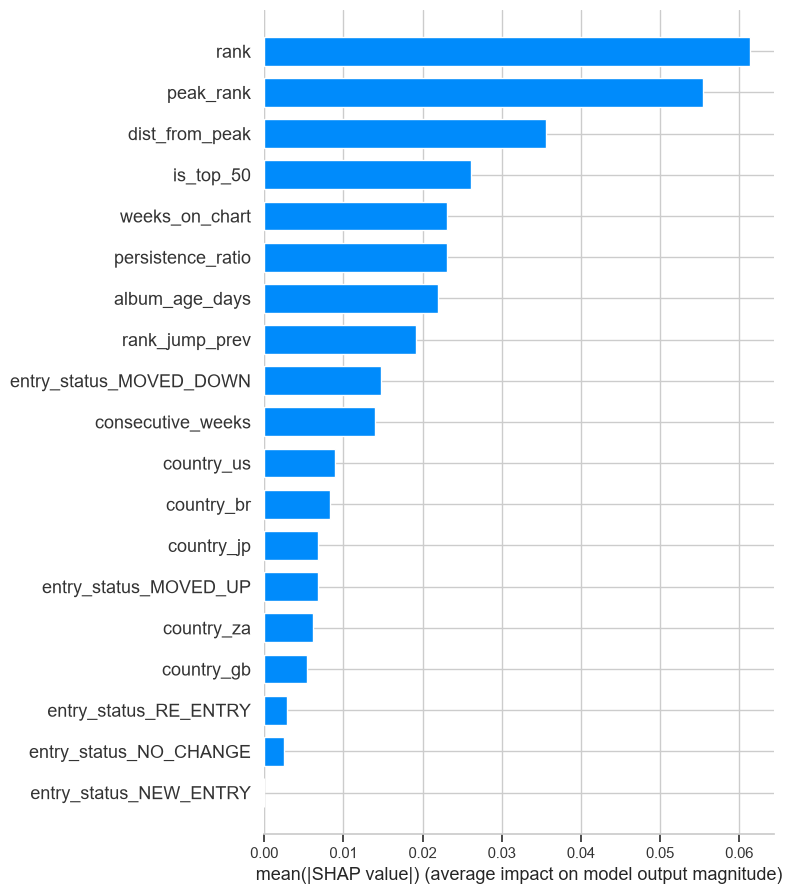

In [12]:
def extract_positive_class_shap(shap_values, n_features):
    """
    Normaliza o retorno do KernelExplainer para sempre obter uma matriz
    (n_amostras, n_features) referente à classe positiva (1), independentemente
    da versão do shap instalada:
    - Lista [shap_classe_0, shap_classe_1]           -> versões mais antigas
    - Array 3D (n_amostras, n_features, n_classes)   -> versões mais recentes
    - Array 2D (n_amostras, n_features)              -> saída já unidimensional
    """
    if isinstance(shap_values, list):
        vals = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        vals = shap_values[:, :, 1]
    else:
        vals = shap_values

    if vals.shape[1] != n_features:
        vals = vals[:, :n_features]

    return vals


print(f"--- SHAP: Modelo Histórico (M0) ---")
explainer_m0 = shap.KernelExplainer(modelo_m0_referencia.predict_proba, X_sample)
shap_values_m0 = explainer_m0.shap_values(X_sample)

vals_m0 = extract_positive_class_shap(shap_values_m0, X_sample.shape[1])

shap.summary_plot(vals_m0, X_sample, feature_names=features_names, plot_type="bar", show=True)

--- SHAP: Modelo Atualizado (MREC) ---


100%|██████████| 50/50 [00:08<00:00,  5.71it/s]


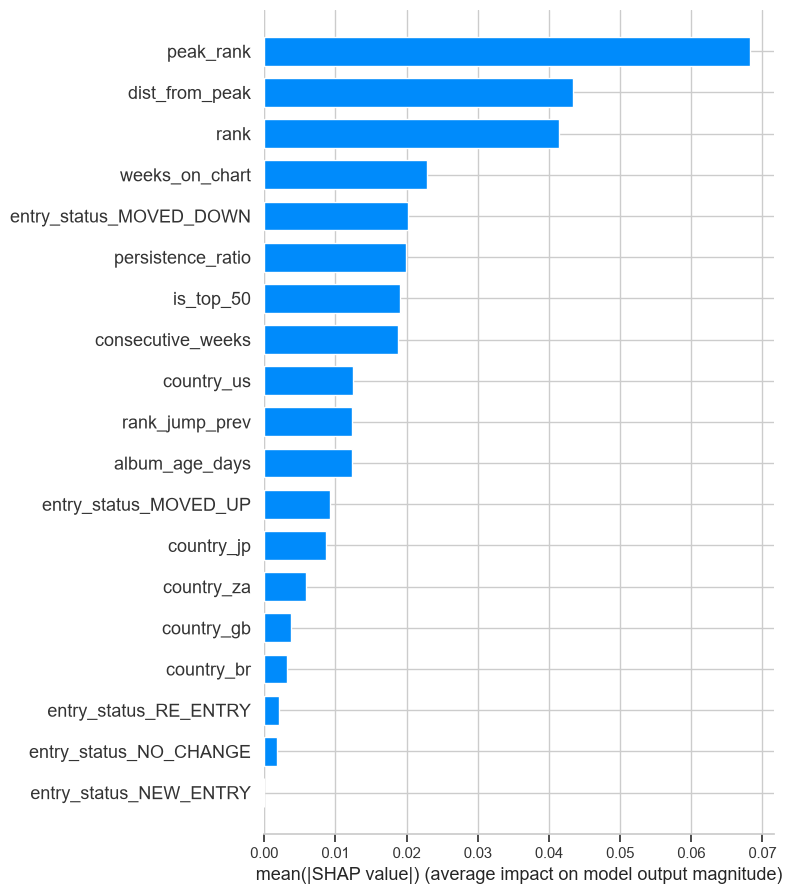

In [13]:
print(f"--- SHAP: Modelo Atualizado ({melhor_nome}) ---")
explainer_upd = shap.KernelExplainer(melhor_modelo.predict_proba, X_sample)
shap_values_upd = explainer_upd.shap_values(X_sample)

vals_upd = extract_positive_class_shap(shap_values_upd, X_sample.shape[1])

shap.summary_plot(vals_upd, X_sample, feature_names=features_names, plot_type="bar", show=True)

In [14]:
# Ranking comparativo da importância média absoluta das variáveis (M0 vs. modelo atualizado)
importancia_m0 = pd.Series(np.abs(vals_m0).mean(axis=0), index=features_names, name='Importância_M0')
importancia_upd = pd.Series(np.abs(vals_upd).mean(axis=0), index=features_names, name=f'Importância_{melhor_nome}')

comparativo_shap = pd.concat([importancia_m0, importancia_upd], axis=1)
comparativo_shap['Variação (%)'] = (
    (comparativo_shap[f'Importância_{melhor_nome}'] - comparativo_shap['Importância_M0'])
    / comparativo_shap['Importância_M0'].replace(0, np.nan)
) * 100
comparativo_shap = comparativo_shap.sort_values('Importância_M0', ascending=False)

print("Comparativo de importância de atributos: M0 (histórico) vs. modelo atualizado")
display(comparativo_shap.round(4))

Comparativo de importância de atributos: M0 (histórico) vs. modelo atualizado


,Importância_M0,Importância_MREC,Variação (%)
rank,0.0613,0.0414,-32.5351
peak_rank,0.0554,0.0682,23.1570
dist_from_peak,0.0355,0.0434,22.0309
is_top_50,0.0261,0.0191,-27.1085
weeks_on_chart,0.0231,0.0229,-0.9194
persistence_ratio,0.0230,0.0199,-13.7294
album_age_days,0.0220,0.0123,-43.9635
rank_jump_prev,0.0192,0.0124,-35.5970
entry_status_MOVED_DOWN,0.0147,0.0201,37.0458
consecutive_weeks,0.0140,0.0188,34.4392


> **Roteiro de interpretação (preencher no relatório):** observe se as variáveis no topo do ranking mudaram de posição entre M0 e o modelo atualizado. Se `rank`, `dist_from_peak` ou `rank_jump_prev` permanecerem dominantes em ambos, isso sugere que a *relação* entre dinâmica de ranking e a tendência de subida é estável (baixo concept drift). Se variáveis como `album_age_days` ganharem importância no modelo atualizado, isso é evidência de mudança no padrão de consumo ao longo do tempo.

## 5. Análise de Erros: Falsos Positivos e Falsos Negativos (US11 / RN11.2)

Utilizamos o modelo atualizado selecionado na seção anterior para identificar, em D2, os casos de erro mais "severos" (maior confiança do modelo na predição errada), com exemplos reais de álbuns e artistas.

In [15]:
y_pred_erro = melhor_modelo.predict(X2)
y_prob_erro = melhor_modelo.predict_proba(X2)[:, 1]

d2_analise = d2.reset_index(drop=True).copy()
d2_analise['y_real'] = y2
d2_analise['y_pred'] = y_pred_erro
d2_analise['prob_subida'] = y_prob_erro

falsos_positivos = d2_analise[(d2_analise['y_real'] == 0) & (d2_analise['y_pred'] == 1)].copy()
falsos_negativos = d2_analise[(d2_analise['y_real'] == 1) & (d2_analise['y_pred'] == 0)].copy()

# Severidade: quão longe a probabilidade estava do limiar correto
falsos_positivos['severidade'] = falsos_positivos['prob_subida']
falsos_negativos['severidade'] = 1 - falsos_negativos['prob_subida']

colunas_exibir = ['date', 'country', 'album_name', 'artist_names', 'rank',
                   'previous_rank', 'entry_status', 'prob_subida']

print(f"Total de Falsos Positivos em D2: {len(falsos_positivos):,}")
print(f"Total de Falsos Negativos em D2: {len(falsos_negativos):,}\n")

print("--- Top 5 Falsos Positivos mais severos (modelo previu subida, mas o álbum caiu/manteve) ---")
display(falsos_positivos.sort_values('severidade', ascending=False)[colunas_exibir].head(5))

print("\n--- Top 5 Falsos Negativos mais severos (modelo previu queda, mas o álbum subiu) ---")
display(falsos_negativos.sort_values('severidade', ascending=False)[colunas_exibir].head(5))

Total de Falsos Positivos em D2: 3,614
Total de Falsos Negativos em D2: 15,588

--- Top 5 Falsos Positivos mais severos (modelo previu subida, mas o álbum caiu/manteve) ---


,date,country,album_name,artist_names,rank,previous_rank,entry_status,prob_subida
9966,2025-07-10,gb,Heathen Chemistry,Oasis,90,-1,RE_ENTRY,0.985335
8048,2025-06-26,gb,Reckless (30th Anniversary / Deluxe Edition),Bryan Adams,193,-1,NEW_ENTRY,0.964832
10824,2025-07-17,jp,KinKi Single Selection,KinKi Kids,190,186,MOVED_DOWN,0.956735
28411,2025-11-20,br,Ao Vivo Na Ilha Da Magia,Exaltasamba,195,-1,RE_ENTRY,0.945468
25135,2025-10-30,jp,泣きたくなるほど嬉しい日々に,Creep Hyp,198,-1,RE_ENTRY,0.944926



--- Top 5 Falsos Negativos mais severos (modelo previu queda, mas o álbum subiu) ---


,date,country,album_name,artist_names,rank,previous_rank,entry_status,prob_subida
24261,2025-10-23,jp,NEVER SAY NEVER,ZEROBASEONE,123,42,MOVED_DOWN,0.008381
41320,2026-02-26,jp,DAiLY&LOVE,Number_i,98,56,MOVED_DOWN,0.011749
40416,2026-02-19,gb,Wuthering Heights,Charli xcx,3,-1,NEW_ENTRY,0.020346
8698,2025-06-26,us,KPop Demon Hunters (Soundtrack from the Netfli...,KPop Demon Hunters Cast|HUNTR/X|Saja Boys,6,-1,NEW_ENTRY,0.020756
25394,2025-10-30,gb,West End Girl,Lily Allen,4,-1,NEW_ENTRY,0.021230


> **Roteiro de interpretação (preencher no relatório):** ao observar os exemplos acima, verifique padrões comuns — por exemplo, álbuns muito antigos que tiveram um pico inesperado de audição (ex: viralização, aniversário, morte do artista, uso em trend de redes sociais) tendem a gerar falsos negativos, pois o modelo aprendeu que álbuns antigos raramente sobem. Já falsos positivos podem ocorrer em álbuns recém-lançados que o modelo "espera" continuar subindo, mas que na prática já atingiram seu pico de popularidade.

## 6. Tabela 17 — Avaliação Cega Consolidada em D2 (Item 17 do Edital)

Resultado comparativo formal das quatro estratégias de manutenção sob mudança temporal, com métricas completas, desvio-padrão entre as 3 seeds e variação percentual em relação a M0 (métrica principal: F1-Score).

In [16]:
def fmt(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

def variacao_pct(valor_atual, valor_m0):
    if valor_m0 == 0:
        return "N/A"
    return f"{((valor_atual - valor_m0) / valor_m0) * 100:+.2f}%"

resumos = {
    'M0':   {'dados': 'D0',      'estrategia': 'Treinamento Histórico',    'summary': summary_m0},
    'MFT':  {'dados': 'D0 -> D1', 'estrategia': f'Fine-Tuning ({mft_config_vencedora})', 'summary': summary_mft},
    'MRT':  {'dados': 'D0 + D1', 'estrategia': 'Retreinamento Completo',   'summary': summary_mrt},
    'MREC': {'dados': 'D1',      'estrategia': 'Somente Dados Recentes',  'summary': summary_mrec},
}

f1_m0_ref = summary_m0['F1_mean']

linhas_tabela = []
for nome, info in resumos.items():
    s = info['summary']
    linhas_tabela.append({
        "Modelo": nome,
        "Dados Utilizados": info['dados'],
        "Estratégia": info['estrategia'],
        "Accuracy": fmt(s['Accuracy_mean'], s['Accuracy_std']),
        "Precision": fmt(s['Precision_mean'], s['Precision_std']),
        "Recall": fmt(s['Recall_mean'], s['Recall_std']),
        "F1-Score (métrica principal)": fmt(s['F1_mean'], s['F1_std']),
        "PR-AUC": fmt(s['PR-AUC_mean'], s['PR-AUC_std']),
        "MCC": fmt(s['MCC_mean'], s['MCC_std']),
        "Variação F1 vs. M0": "-" if nome == "M0" else variacao_pct(s['F1_mean'], f1_m0_ref)
    })

tabela_17 = pd.DataFrame(linhas_tabela)

print("=" * 120)
print("             TABELA 17: DESEMPENHO DOS MODELOS NO CONJUNTO FUTURO (D2)             ")
print("=" * 120)
display(tabela_17)

             TABELA 17: DESEMPENHO DOS MODELOS NO CONJUNTO FUTURO (D2)             


,Modelo,Dados Utilizados,Estratégia,Accuracy,Precision,Recall,F1-Score (métrica principal),PR-AUC,MCC,Variação F1 vs. M0
0,M0,D0,Treinamento Histórico,0.6297 ± 0.0022,0.5676 ± 0.0095,0.1844 ± 0.0095,0.2783 ± 0.0107,0.5085 ± 0.0038,0.1404 ± 0.0068,-
1,MFT,D0 -> D1,Fine-Tuning (Config A (conservadora)),0.6337 ± 0.0011,0.5895 ± 0.0209,0.1832 ± 0.0307,0.2781 ± 0.0325,0.5197 ± 0.0022,0.1524 ± 0.0021,-0.06%
2,MRT,D0 + D1,Retreinamento Completo,0.6319 ± 0.0010,0.5705 ± 0.0027,0.2002 ± 0.0114,0.2962 ± 0.0123,0.5161 ± 0.0030,0.1491 ± 0.0043,+6.45%
3,MREC,D1,Somente Dados Recentes,0.6250 ± 0.0022,0.5365 ± 0.0082,0.2344 ± 0.0160,0.3260 ± 0.0148,0.5044 ± 0.0045,0.1381 ± 0.0053,+17.15%
